# ARIMA Pipeline: Role Demand Forecasting

End-to-end pipeline for role-level job demand forecasting using ARIMA.

Workflow:
1. Load and validate dataset
2. Preprocess and normalize schema
3. EDA and visualization
4. Feature engineering
5. Order search, training, and cross-validation
6. Evaluation and ranking
7. Save artifacts
8. Compare with Prophet results (if available)

In [11]:
from pathlib import Path
import json
import re
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error, mean_absolute_error

warnings.filterwarnings('ignore')

In [12]:
# Configuration and paths
def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'Job_pipeline').exists():
            return candidate
    return start

PROJECT_ROOT = find_project_root(Path.cwd())
DATA_PATH = PROJECT_ROOT / 'Job_pipeline' / 'data' / 'processed' / 'afriwork_all_jobs_20260310_124628.csv'

OUTPUT_ROOT = PROJECT_ROOT / 'model' / 'timeseries' / 'artifacts'
MODEL_NAME = 'arima'
MODEL_DIR = OUTPUT_ROOT / 'models' / MODEL_NAME
FORECAST_DIR = OUTPUT_ROOT / 'forecasts'
METRIC_DIR = OUTPUT_ROOT / 'metrics'
PLOT_DIR = OUTPUT_ROOT / 'plots' / MODEL_NAME

for folder in [MODEL_DIR, FORECAST_DIR, METRIC_DIR, PLOT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print(f'Project root: {PROJECT_ROOT}')
print(f'Data path: {DATA_PATH}')

Project root: c:\Users\user\Desktop\5th\VentureScope\Data-ML
Data path: c:\Users\user\Desktop\5th\VentureScope\Data-ML\Job_pipeline\data\processed\afriwork_all_jobs_20260310_124628.csv


In [13]:
# Load dataset and normalize schema
raw_df = pd.read_csv(DATA_PATH)
print('Raw shape:', raw_df.shape)

required_columns = {'normalized_title', 'job_id'}
missing_required = required_columns.difference(raw_df.columns)
if missing_required:
    raise ValueError(f'Missing required columns: {sorted(missing_required)}')

date_source_col = None
for candidate in ['timestamp', 'year_month', 'month']:
    if candidate in raw_df.columns:
        date_source_col = candidate
        break
if date_source_col is None:
    raise ValueError("Expected one of date columns: ['timestamp', 'year_month', 'month']")

df = raw_df.copy()
df['event_date'] = pd.to_datetime(df[date_source_col], errors='coerce')
df['role'] = df['normalized_title'].astype(str).str.strip()

before_dedup = len(df)
df = df.drop_duplicates(subset=['job_id'])

df = df.dropna(subset=['event_date', 'role']).copy()
df = df[df['role'] != '']

print('Date source:', date_source_col)
print('Removed duplicates:', before_dedup - len(df))
print('Cleaned shape:', df.shape)
df[['job_id', 'normalized_title', 'role', 'event_date']].head()

Raw shape: (3105, 15)
Date source: timestamp
Removed duplicates: 541
Cleaned shape: (2564, 17)


,job_id,normalized_title,role,event_date
0,db7e5f29ad8acd4b,Frontend Developer,Frontend Developer,2023-05-02 12:21:08.391921+00:00
1,2fde0601f1cd3954,Mobile Developer,Mobile Developer,2026-03-09 13:12:52.043397+00:00
2,3916c66c1af1e2ab,Data Analyst,Data Analyst,2026-03-09 08:07:18.877749+00:00
3,a3cdc14490e42844,UI/UX Designer,UI/UX Designer,2026-03-07 10:13:36.992229+00:00
4,cfec2ff86e6c086c,Other,Other,2026-03-06 20:44:53.344375+00:00


## EDA and Visualization
Inspect role coverage, total monthly demand, distribution, and temporal dependence with ACF/PACF.

In [14]:
print('Unique roles:', df['role'].nunique())
print('Date range:', df['event_date'].min(), 'to', df['event_date'].max())

monthly_total = (
    df.assign(month=df['event_date'].dt.to_period('M').dt.to_timestamp())
      .groupby('month', as_index=False)
      .size()
      .rename(columns={'size': 'job_count'})
)

top_roles = df['role'].value_counts().head(15)
display(monthly_total.head())
display(top_roles.to_frame('posting_count'))

Unique roles: 22
Date range: 2022-08-14 17:47:38.768705+00:00 to 2026-03-09 13:12:52.043397+00:00


,month,job_count
0,2022-08-01,1
1,2022-09-01,2
2,2022-10-01,24
3,2022-11-01,21
4,2022-12-01,48


,posting_count
role,
Frontend Developer,294
Full Stack Developer,290
UI/UX Designer,285
Mobile Developer,273
Product Manager,268
Software Engineer,238
Backend Developer,221
Other,170
Data Analyst,84


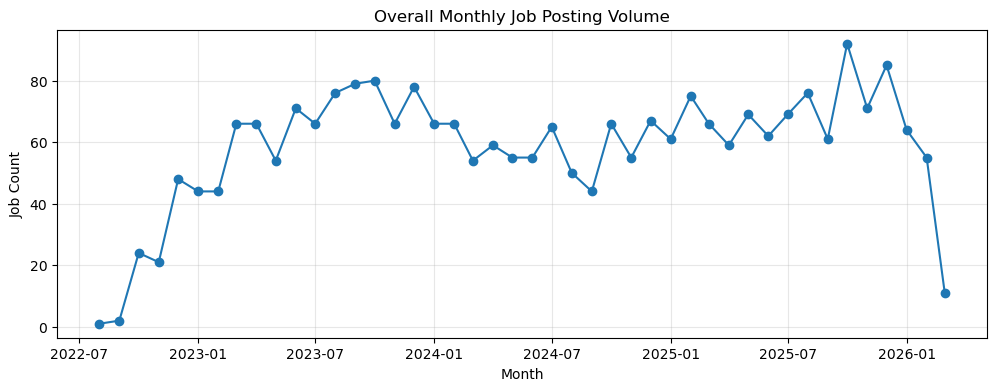

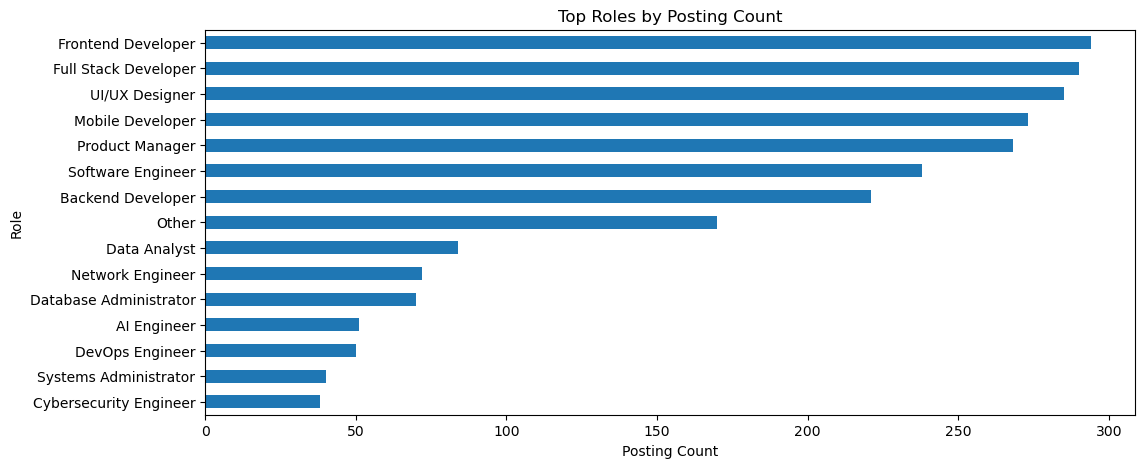

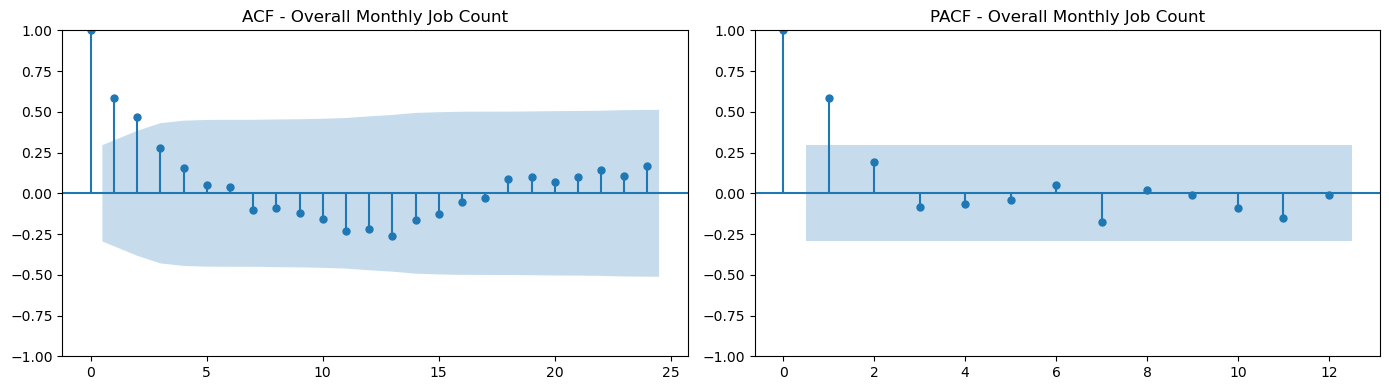

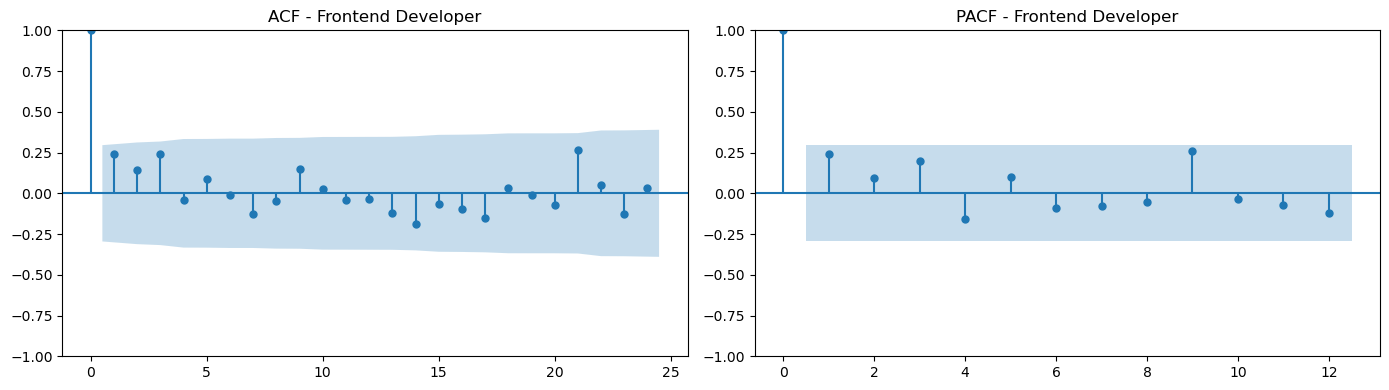

In [15]:
plt.figure(figsize=(12, 4))
plt.plot(monthly_total['month'], monthly_total['job_count'], marker='o')
plt.title('Overall Monthly Job Posting Volume')
plt.xlabel('Month')
plt.ylabel('Job Count')
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(12, 5))
top_roles.sort_values().plot(kind='barh')
plt.title('Top Roles by Posting Count')
plt.xlabel('Posting Count')
plt.ylabel('Role')
plt.show()

# ACF/PACF on overall monthly demand
overall_series = monthly_total.set_index('month')['job_count'].asfreq('MS').fillna(0)
overall_lags = min(24, max(1, len(overall_series) - 1))
overall_pacf_lags = min(12, max(1, len(overall_series) // 2 - 1))

if len(overall_series) > 4:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    plot_acf(overall_series, lags=overall_lags, ax=axes[0])
    axes[0].set_title('ACF - Overall Monthly Job Count')
    plot_pacf(overall_series, lags=overall_pacf_lags, ax=axes[1], method='ywm')
    axes[1].set_title('PACF - Overall Monthly Job Count')
    plt.tight_layout()
    plt.show()

# ACF/PACF on the highest-volume role
top_role_name = top_roles.index[0] if len(top_roles) > 0 else None
if top_role_name is not None:
    top_role_series = (
        modeling_df[modeling_df['role'] == top_role_name]
        .sort_values('month')
        .set_index('month')['job_count']
        .asfreq('MS')
        .fillna(0)
    )
    role_lags = min(24, max(1, len(top_role_series) - 1))
    role_pacf_lags = min(12, max(1, len(top_role_series) // 2 - 1))

    if len(top_role_series) > 4:
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        plot_acf(top_role_series, lags=role_lags, ax=axes[0])
        axes[0].set_title(f'ACF - {top_role_name}')
        plot_pacf(top_role_series, lags=role_pacf_lags, ax=axes[1], method='ywm')
        axes[1].set_title(f'PACF - {top_role_name}')
        plt.tight_layout()
        plt.show()

## Feature Engineering
Build monthly role-level panel and lag/rolling features for diagnostics.

In [17]:
df['month'] = df['event_date'].dt.to_period('M').dt.to_timestamp()
monthly_role = (
    df.groupby(['role', 'month'], as_index=False)
      .size()
      .rename(columns={'size': 'job_count'})
)

month_index = pd.date_range(monthly_role['month'].min(), monthly_role['month'].max(), freq='MS')
expanded_frames = []
for role_name, role_df in monthly_role.groupby('role'):
    role_df = role_df.set_index('month').reindex(month_index).rename_axis('month').reset_index()
    role_df['role'] = role_name
    role_df['job_count'] = role_df['job_count'].fillna(0)
    role_df['lag_1'] = role_df['job_count'].shift(1)
    role_df['lag_3'] = role_df['job_count'].shift(3)
    role_df['roll_mean_3'] = role_df['job_count'].rolling(3).mean()
    expanded_frames.append(role_df)

modeling_df = pd.concat(expanded_frames, ignore_index=True)
modeling_df = modeling_df.sort_values(['role', 'month']).reset_index(drop=True)

final_modeling_view = modeling_df[['month', 'role', 'job_count']].copy()
print('Modeling shape:', final_modeling_view.shape)
display(final_modeling_view.head())

Modeling shape: (968, 3)


,month,role,job_count
0,2022-08-01,AI Engineer,0.0
1,2022-09-01,AI Engineer,0.0
2,2022-10-01,AI Engineer,0.0
3,2022-11-01,AI Engineer,0.0
4,2022-12-01,AI Engineer,0.0


In [18]:
# Role selection and robust ARIMA candidate orders
min_months = 12
max_roles = 20

# Curated grid balances robustness and runtime
order_grid = [
    (0, 1, 1), (1, 1, 0), (1, 1, 1), (2, 1, 1),
    (1, 0, 1), (2, 0, 2), (3, 1, 1), (3, 1, 2),
    (2, 1, 2), (0, 2, 1), (1, 2, 1), (2, 2, 2),
]

role_stats = modeling_df.groupby('role', as_index=False).agg(
    total_jobs=('job_count', 'sum'),
    n_months=('month', 'nunique')
)
eligible_roles = (
    role_stats[role_stats['n_months'] >= min_months]
    .sort_values('total_jobs', ascending=False)
    .head(max_roles)['role']
    .tolist()
)

print('Eligible roles:', len(eligible_roles))
display(role_stats.sort_values('total_jobs', ascending=False).head(10))

Eligible roles: 20


,role,total_jobs,n_months
9,Frontend Developer,294.0,44
10,Full Stack Developer,290.0,44
21,UI/UX Designer,285.0,44
13,Mobile Developer,273.0,44
16,Product Manager,268.0,44
19,Software Engineer,238.0,44
1,Backend Developer,221.0,44
15,Other,170.0,44
4,Data Analyst,84.0,44
14,Network Engineer,72.0,44


## Training, CV, Forecasting
Run expanding-window cross-validation and fit best ARIMA order per role.

In [19]:
horizon_months = 6
cv_horizon_months = 3
min_train_months = 12
min_cv_splits = 3

best_models = {}
best_orders = {}
forecast_rows = []
evaluation_rows = []
prediction_rows = []

for role_name in eligible_roles:
    role_series = modeling_df[modeling_df['role'] == role_name].sort_values('month')
    y = role_series['job_count'].astype(float).values

    if len(y) < (min_train_months + cv_horizon_months + 1):
        continue

    # Use log transform for heavy-tailed count series
    use_log = np.all(y >= 0) and (np.percentile(y, 95) > (2.0 * max(np.percentile(y, 50), 1.0)))
    if use_log:
        to_model = np.log1p(y)
        from_model = np.expm1
    else:
        to_model = y.copy()
        from_model = lambda x: x

    candidate_rows = []
    best_rmse = np.inf
    best_mae = np.inf
    best_order = None
    best_baseline_rmse = np.nan
    best_baseline_mae = np.nan

    # Rolling-origin, multi-step CV over candidate ARIMA orders
    for order in order_grid:
        all_true = []
        all_pred = []
        baseline_true = []
        baseline_pred = []
        split_count = 0

        last_start = len(y) - cv_horizon_months
        for split_idx in range(min_train_months, last_start + 1):
            train_raw = y[:split_idx]
            test_raw = y[split_idx: split_idx + cv_horizon_months]
            train_mod = to_model[:split_idx]

            if len(test_raw) < cv_horizon_months:
                continue

            try:
                model = ARIMA(train_mod, order=order).fit()
                pred_mod = model.forecast(steps=cv_horizon_months)
                pred_raw = np.asarray(from_model(pred_mod), dtype=float)
                pred_raw = np.clip(pred_raw, 0, None)

                all_true.extend(test_raw.tolist())
                all_pred.extend(pred_raw.tolist())

                # Naive baseline: repeat the last observed value
                naive_vals = np.repeat(train_raw[-1], cv_horizon_months)
                baseline_true.extend(test_raw.tolist())
                baseline_pred.extend(naive_vals.tolist())
                split_count += 1
            except Exception:
                continue

        if split_count >= min_cv_splits and len(all_true) > 0:
            rmse = float(mean_squared_error(all_true, all_pred, squared=False))
            mae = float(mean_absolute_error(all_true, all_pred))

            baseline_rmse = float(mean_squared_error(baseline_true, baseline_pred, squared=False))
            baseline_mae = float(mean_absolute_error(baseline_true, baseline_pred))

            candidate_rows.append({
                'role': role_name,
                'order': str(order),
                'rmse': rmse,
                'mae': mae,
                'baseline_rmse': baseline_rmse,
                'baseline_mae': baseline_mae,
                'cv_splits': split_count,
                'used_log_transform': use_log,
            })

            if (rmse < best_rmse) or (np.isclose(rmse, best_rmse) and mae < best_mae):
                best_rmse = rmse
                best_mae = mae
                best_order = order
                best_baseline_rmse = baseline_rmse
                best_baseline_mae = baseline_mae

    if best_order is None:
        continue

    # Fit best model on full history
    final_mod_series = to_model
    final_model = ARIMA(final_mod_series, order=best_order).fit()
    best_models[role_name] = final_model
    best_orders[role_name] = best_order

    forecast_res = final_model.get_forecast(steps=horizon_months)
    mean_mod = np.asarray(forecast_res.predicted_mean, dtype=float)
    mean_raw = np.asarray(from_model(mean_mod), dtype=float)
    mean_raw = np.clip(mean_raw, 0, None)

    conf_int = forecast_res.conf_int(alpha=0.2)
    if isinstance(conf_int, pd.DataFrame):
        lower_mod = conf_int.iloc[:, 0].values
        upper_mod = conf_int.iloc[:, 1].values
    else:
        lower_mod = conf_int[:, 0]
        upper_mod = conf_int[:, 1]

    lower_raw = np.clip(np.asarray(from_model(lower_mod), dtype=float), 0, None)
    upper_raw = np.clip(np.asarray(from_model(upper_mod), dtype=float), 0, None)

    future_months = pd.date_range(
        role_series['month'].max() + pd.offsets.MonthBegin(1),
        periods=horizon_months,
        freq='MS'
    )

    for d, yhat, lo, hi in zip(future_months, mean_raw, lower_raw, upper_raw):
        forecast_rows.append({
            'role': role_name,
            'ds': d,
            'yhat': float(yhat),
            'yhat_lower': float(lo),
            'yhat_upper': float(hi),
        })

    prediction_rows.append({
        'role': role_name,
        'model': 'arima',
        'pred_next_6m_sum': float(np.sum(mean_raw)),
        'pred_next_6m_mean': float(np.mean(mean_raw)),
        'best_order': str(best_order),
        'used_log_transform': use_log,
    })

    rmse_improvement_pct = (
        (best_baseline_rmse - best_rmse) / best_baseline_rmse * 100
        if best_baseline_rmse and not np.isclose(best_baseline_rmse, 0)
        else np.nan
    )

    evaluation_rows.append({
        'role': role_name,
        'model': 'arima',
        'order': str(best_order),
        'rmse': best_rmse,
        'mae': best_mae,
        'baseline_rmse': best_baseline_rmse,
        'baseline_mae': best_baseline_mae,
        'rmse_improvement_pct_vs_naive': rmse_improvement_pct,
        'used_log_transform': use_log,
    })

arima_forecasts_df = pd.DataFrame(forecast_rows)
evaluation_df = pd.DataFrame(evaluation_rows).sort_values(['rmse', 'mae'])
predictions_df = pd.DataFrame(prediction_rows).sort_values('pred_next_6m_sum', ascending=False)

print('Trained ARIMA roles:', len(best_models))
display(evaluation_df.head(10))
display(predictions_df.head(10))

Trained ARIMA roles: 20


,role,model,order,rmse,mae,baseline_rmse,baseline_mae,rmse_improvement_pct_vs_naive,used_log_transform
19,Cloud Engineer,arima,"(2, 1, 1)",0.392224,0.322374,0.596285,0.355556,34.222085,False
18,Machine Learning Engineer,arima,"(1, 0, 1)",0.642275,0.516298,0.849837,0.544444,24.423648,False
17,Data Scientist,arima,"(1, 0, 1)",0.654074,0.592480,0.869227,0.533333,24.752182,False
15,QA Engineer,arima,"(2, 0, 2)",0.920597,0.595605,1.337494,1.011111,31.169961,True
16,Site Reliability Engineer,arima,"(0, 1, 1)",1.134566,0.916222,1.269296,0.966667,10.614530,True
13,Systems Administrator,arima,"(0, 1, 1)",1.147722,0.875080,1.549193,1.200000,25.914842,True
11,AI Engineer,arima,"(1, 0, 1)",1.270496,0.946458,1.643168,1.300000,22.680093,True
12,DevOps Engineer,arima,"(1, 1, 0)",1.281822,1.049570,1.516575,1.233333,15.479164,True
14,Cybersecurity Engineer,arima,"(1, 0, 1)",1.413800,1.052284,1.822696,1.388889,22.433615,True
8,Data Analyst,arima,"(1, 0, 1)",1.569362,1.314127,1.983263,1.644444,20.869688,False


,role,model,pred_next_6m_sum,pred_next_6m_mean,best_order,used_log_transform
1,Full Stack Developer,arima,36.793460,6.132243,"(0, 1, 1)",False
2,UI/UX Designer,arima,35.166390,5.861065,"(1, 0, 1)",False
7,Other,arima,31.386716,5.231119,"(3, 1, 1)",False
5,Software Engineer,arima,27.981030,4.663505,"(1, 0, 1)",False
4,Product Manager,arima,26.612893,4.435482,"(1, 1, 1)",False
6,Backend Developer,arima,25.188047,4.198008,"(0, 1, 1)",True
3,Mobile Developer,arima,17.889933,2.981656,"(1, 1, 1)",True
0,Frontend Developer,arima,12.610095,2.101683,"(0, 1, 1)",True
8,Data Analyst,arima,10.135083,1.689180,"(1, 0, 1)",False
9,Network Engineer,arima,10.056264,1.676044,"(0, 1, 1)",True


## Evaluation Guide
Use this section to interpret the ARIMA evaluation output before selecting a model.

- RMSE: Root Mean Squared Error. Penalizes large misses more strongly. Lower is better.
- MAE: Mean Absolute Error. Average absolute miss in job-count units. Lower is better.
- Baseline RMSE and Baseline MAE: Error from a naive forecast that repeats the last observed value.
- RMSE Improvement % vs Naive: Positive values indicate ARIMA outperforms the naive baseline.
- used_log_transform: Indicates whether log1p/expm1 stabilization was used for that role.

Practical reading:
- Prefer roles with lower RMSE and MAE.
- Give higher confidence to roles where ARIMA also beats baseline by a meaningful margin.
- If improvement vs baseline is near zero or negative, forecast signal may be weak for that role.

In [20]:
# Evaluation diagnostics table
if evaluation_df.empty:
    print('No evaluation rows available.')
else:
    eval_diag = evaluation_df.copy()
    eval_diag['rmse_rank'] = eval_diag['rmse'].rank(method='dense')
    eval_diag['mae_rank'] = eval_diag['mae'].rank(method='dense')
    eval_diag['avg_rank'] = (eval_diag['rmse_rank'] + eval_diag['mae_rank']) / 2
    eval_diag = eval_diag.sort_values(['avg_rank', 'rmse', 'mae']).reset_index(drop=True)

    display(eval_diag.head(15))

    strong_roles = eval_diag[eval_diag['rmse_improvement_pct_vs_naive'] > 10]
    print(f"Roles with >10% RMSE improvement vs naive: {len(strong_roles)}")

,role,model,order,rmse,mae,baseline_rmse,baseline_mae,rmse_improvement_pct_vs_naive,used_log_transform,rmse_rank,mae_rank,avg_rank
0,Cloud Engineer,arima,"(2, 1, 1)",0.392224,0.322374,0.596285,0.355556,34.222085,False,1.0,1.0,1.0
1,Machine Learning Engineer,arima,"(1, 0, 1)",0.642275,0.516298,0.849837,0.544444,24.423648,False,2.0,2.0,2.0
2,Data Scientist,arima,"(1, 0, 1)",0.654074,0.592480,0.869227,0.533333,24.752182,False,3.0,3.0,3.0
3,QA Engineer,arima,"(2, 0, 2)",0.920597,0.595605,1.337494,1.011111,31.169961,True,4.0,4.0,4.0
4,Site Reliability Engineer,arima,"(0, 1, 1)",1.134566,0.916222,1.269296,0.966667,10.614530,True,5.0,6.0,5.5
5,Systems Administrator,arima,"(0, 1, 1)",1.147722,0.875080,1.549193,1.200000,25.914842,True,6.0,5.0,5.5
6,AI Engineer,arima,"(1, 0, 1)",1.270496,0.946458,1.643168,1.300000,22.680093,True,7.0,7.0,7.0
7,DevOps Engineer,arima,"(1, 1, 0)",1.281822,1.049570,1.516575,1.233333,15.479164,True,8.0,8.0,8.0
8,Cybersecurity Engineer,arima,"(1, 0, 1)",1.413800,1.052284,1.822696,1.388889,22.433615,True,9.0,9.0,9.0
9,Data Analyst,arima,"(1, 0, 1)",1.569362,1.314127,1.983263,1.644444,20.869688,False,10.0,10.0,10.0


Roles with >10% RMSE improvement vs naive: 20


In [21]:
# Final prediction: role with highest predicted demand
if predictions_df.empty:
    print('No ARIMA predictions available.')
    top_role_arima = None
else:
    top_row = predictions_df.iloc[0]
    top_role_arima = top_row['role']
    print(f"ARIMA top predicted role: {top_role_arima}")
    print(f"Next 6-month predicted total: {top_row['pred_next_6m_sum']:.2f}")

ARIMA top predicted role: Full Stack Developer
Next 6-month predicted total: 36.79


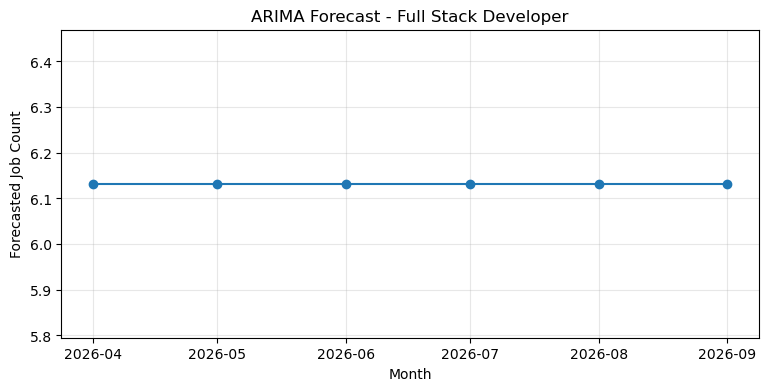

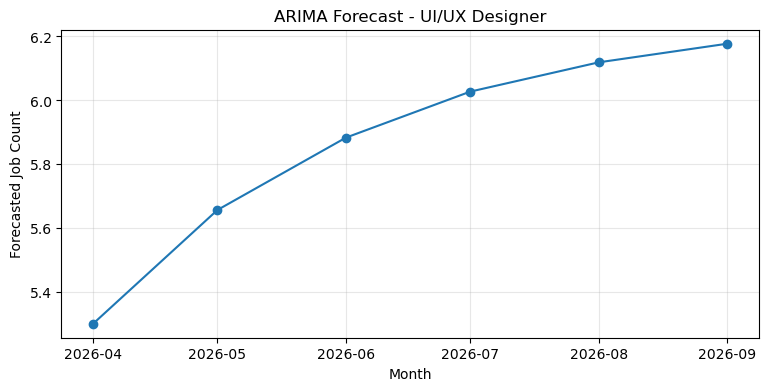

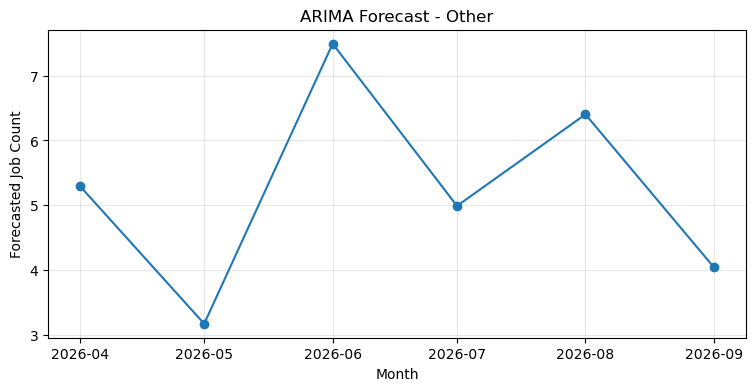

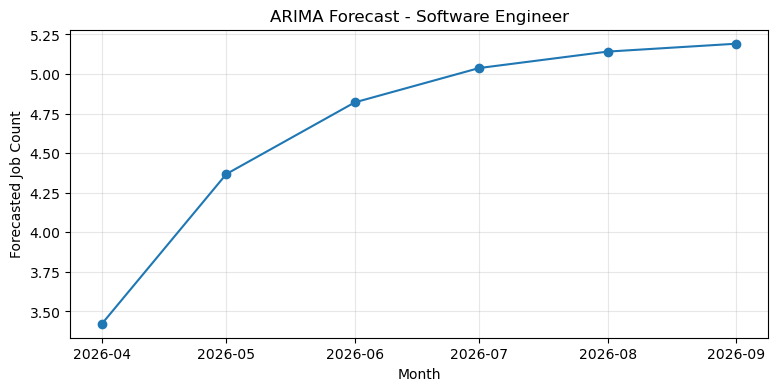

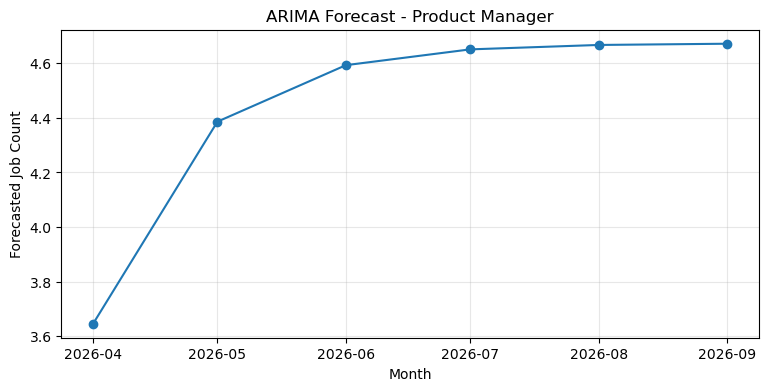

In [22]:
# Visualization: top 5 predicted role forecasts
plot_roles = predictions_df.head(5)['role'].tolist() if not predictions_df.empty else []

for role_name in plot_roles:
    temp = arima_forecasts_df[arima_forecasts_df['role'] == role_name].copy()
    if temp.empty:
        continue
    plt.figure(figsize=(9, 4))
    plt.plot(temp['ds'], temp['yhat'], marker='o')
    plt.title(f'ARIMA Forecast - {role_name}')
    plt.xlabel('Month')
    plt.ylabel('Forecasted Job Count')
    plt.grid(alpha=0.3)
    plt.show()

In [23]:
# Save artifacts
def slugify(value: str) -> str:
    return re.sub(r'[^a-z0-9]+', '_', str(value).lower()).strip('_')

for role_name, model in best_models.items():
    model_path = MODEL_DIR / f'arima_{slugify(role_name)}.pkl'
    joblib.dump(model, model_path)

final_modeling_view.to_csv(OUTPUT_ROOT / 'modeling_dataset_month_role_job_count.csv', index=False)
evaluation_df.to_csv(METRIC_DIR / 'arima_cv_metrics.csv', index=False)
predictions_df.to_csv(FORECAST_DIR / 'arima_role_predictions.csv', index=False)

if not arima_forecasts_df.empty:
    arima_forecasts_df.to_csv(FORECAST_DIR / 'arima_forecasts_all_roles.csv', index=False)

summary_payload = {
    'model': 'arima',
    'top_role': top_role_arima,
    'n_roles_trained': len(best_models)
}
with open(METRIC_DIR / 'arima_summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary_payload, f, indent=2)

print('Saved ARIMA artifacts.')

Saved ARIMA artifacts.


In [24]:
# Compare ARIMA vs Prophet metrics if Prophet metrics exist
arima_metrics_path = METRIC_DIR / 'arima_cv_metrics.csv'
prophet_metrics_path = METRIC_DIR / 'prophet_cv_metrics.csv'

if arima_metrics_path.exists() and prophet_metrics_path.exists():
    a = pd.read_csv(arima_metrics_path)
    p = pd.read_csv(prophet_metrics_path)

    a_mean_rmse = a['rmse'].dropna().mean() if 'rmse' in a.columns else np.nan
    p_mean_rmse = p['rmse'].dropna().mean() if 'rmse' in p.columns else np.nan

    comparison = pd.DataFrame({
        'model': ['arima', 'prophet'],
        'mean_cv_rmse': [a_mean_rmse, p_mean_rmse]
    }).sort_values('mean_cv_rmse')

    display(comparison)
    best_model = comparison.iloc[0]['model']
    print(f'Best model by mean CV RMSE: {best_model}')
else:
    print('Run prophet_pipeline.ipynb to enable side-by-side model comparison.')

,model,mean_cv_rmse
0,arima,1.930095
1,prophet,NaN


Best model by mean CV RMSE: arima
